In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

## 1. Загрузка данных

In [12]:
train_noisy = pd.read_csv('train.csv', header=None).to_numpy()
train_clean = pd.read_csv('etalon_for_train.csv', header=None).to_numpy()
test_noisy = pd.read_csv('test.csv', header=None).to_numpy()
test_clean = pd.read_csv('etalon_for_test.csv', header=None).to_numpy()

# Параметры
dt = 0.05
input_len = 4000      # 200 с
pred_len = int(50/dt) # 1000 точек

X_train = train_noisy[:, :input_len]
Y_train = train_clean[:, input_len:input_len+pred_len]

X_test = test_noisy[:, :input_len]
Y_test = test_clean[:, input_len:input_len+pred_len]

## 2. Нормализация

In [13]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
Y_train_scaled = scaler_Y.fit_transform(Y_train)
X_test_scaled = scaler_X.transform(X_test)
Y_test_scaled = scaler_Y.transform(Y_test)

## 3. Обучение моделей

In [14]:
model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                     solver='adam', max_iter=200, random_state=42)
model.fit(X_train_scaled, Y_train_scaled)

MLPRegressor(hidden_layer_sizes=(100, 50), random_state=42)

## 4. Прогноз и обратное масштабирование

In [15]:
Y_pred_scaled = model.predict(X_test_scaled)
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)

## 5. Расчёт ME и RMS

In [16]:
L = Y_test.shape[0]           # количество тестовых реализаций (500)
error = Y_pred - Y_test        # ошибка для каждой реализации и каждого момента времени
ME = np.mean(error, axis=0)    # средняя ошибка по реализациям (размер pred_len)

# Вычитаем ME из каждой реализации (broadcasting)
error_centered = error - ME
RMS = np.sqrt(np.sum(error_centered**2, axis=0) / (L - 1))

# Общие показатели
total_ME = np.mean(ME)
total_RMS = np.mean(RMS)
print(f"Средняя ошибка (ME) по всем моментам: {total_ME:.6f}")
print(f"Средняя RMS по всем моментам: {total_RMS:.6f}")

Средняя ошибка (ME) по всем моментам: 0.005377
Средняя RMS по всем моментам: 0.571091


## 6. Визуализация

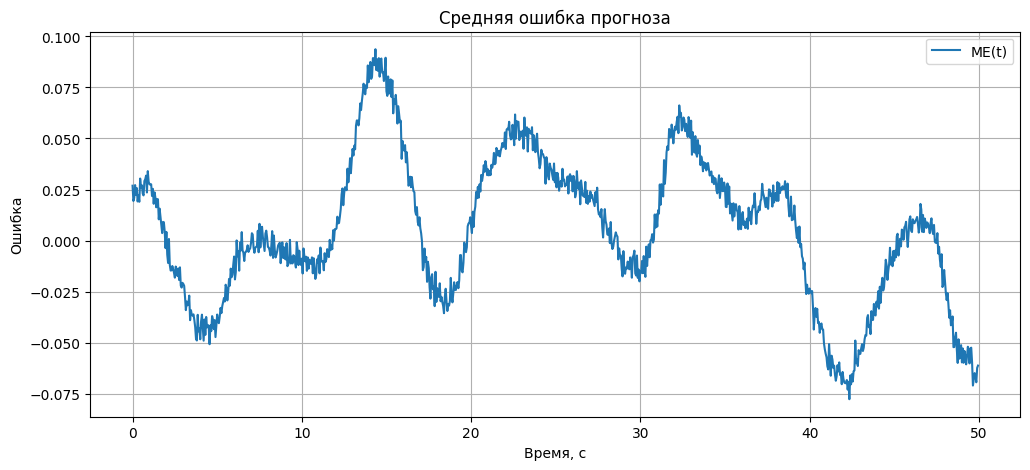

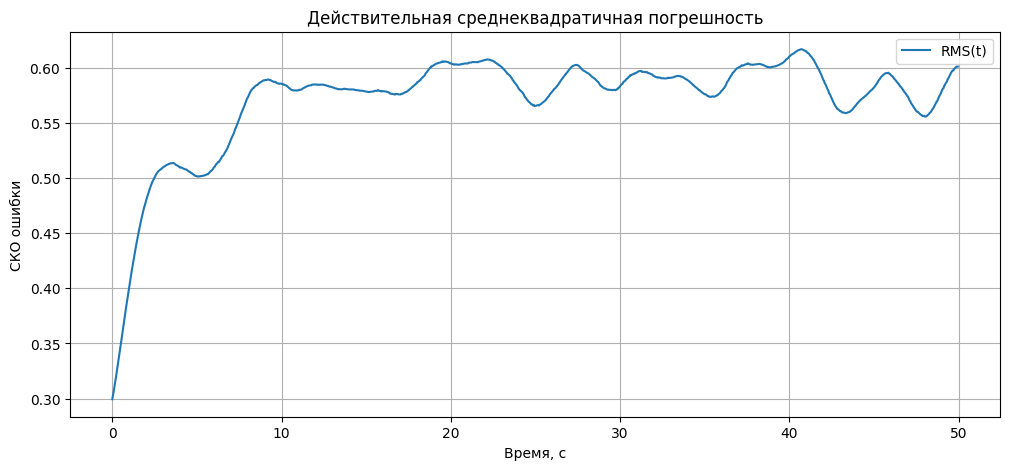

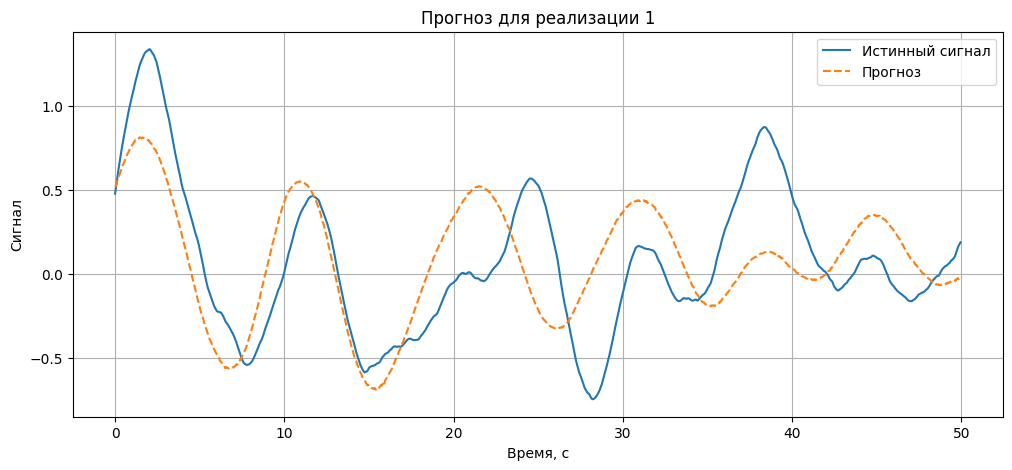

In [17]:
t = np.arange(pred_len) * dt

plt.figure(figsize=(12, 5))
plt.plot(t, ME, label='ME(t)')
plt.xlabel('Время, с')
plt.ylabel('Ошибка')
plt.title('Средняя ошибка прогноза')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, RMS, label='RMS(t)')
plt.xlabel('Время, с')
plt.ylabel('СКО ошибки')
plt.title('Действительная среднеквадратичная погрешность')
plt.grid(True)
plt.legend()
plt.show()

# Пример прогноза одной реализации
idx = 0
plt.figure(figsize=(12, 5))
plt.plot(t, Y_test[idx], label='Истинный сигнал')
plt.plot(t, Y_pred[idx], '--', label='Прогноз')
plt.xlabel('Время, с')
plt.ylabel('Сигнал')
plt.title(f'Прогноз для реализации {idx+1}')
plt.legend()
plt.grid(True)
plt.show()